In [69]:
import requests
import zipfile
import io
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kstest
import numpy as np
from scipy.stats import norm, skewnorm, t
from datetime import datetime
from datetime import timedelta


url = 'https://codesignal-attachments.s3.amazonaws.com/uploads/1733137791660/MarketDataAndOrders.zip'

response = requests.get(url)

if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
        file_list = zip_file.namelist()
        
        csv_files = [file for file in file_list if file.endswith('.csv')]
        
        if len(csv_files) >= 1:
            for csv_file in csv_files:
                var_name = csv_file.replace('.csv', '').replace('-', '_').replace(' ', '_')
                globals()[var_name] = pd.read_csv(zip_file.open(csv_file))
                print(f"Loaded {csv_file} into variable '{var_name}'")
        else:
            print("No CSV files found in the ZIP archive.")
else:
    print(f"Failed to download file. Status code: {response.status_code}")
    



Loaded market_data.csv into variable 'market_data'
Loaded orders.csv into variable 'orders'


In [89]:
print(market_data.head(10).to_string())

         date            timestamp symbol  bid_price  ask_price
0  2023-01-03  2023-01-03 14:31:00    ACN     269.31     270.29
1  2023-01-03  2023-01-03 14:32:00    ACN     269.69     270.80
2  2023-01-03  2023-01-03 14:33:00    ACN     270.40     270.95
3  2023-01-03  2023-01-03 14:34:00    ACN     271.16     271.96
4  2023-01-03  2023-01-03 14:35:00    ACN     270.71     271.44
5  2023-01-03  2023-01-03 14:36:00    ACN     270.80     271.31
6  2023-01-03  2023-01-03 14:37:00    ACN     270.80     271.20
7  2023-01-03  2023-01-03 14:38:00    ACN     271.23     271.51
8  2023-01-03  2023-01-03 14:39:00    ACN     271.48     271.78
9  2023-01-03  2023-01-03 14:40:00    ACN     271.80     272.17


In [23]:
print(orders.head(20).to_string())

          date            timestamp symbol order_status   price  side  quantity order_id
0   2023-01-03  2023-01-03 14:34:31    ACN       CREATE  271.95  SELL     273.0  ACN_S_0
1   2023-01-03  2023-01-03 14:35:18    ACN       CANCEL    0.00  SELL     273.0  ACN_S_0
2   2023-01-03  2023-01-03 14:51:14    ACN       CREATE  271.32  SELL     273.0  ACN_S_1
3   2023-01-03  2023-01-03 14:52:28    ACN       CANCEL    0.00  SELL     273.0  ACN_S_1
4   2023-01-03  2023-01-03 15:00:09    ACN       CREATE  269.04   BUY     273.0  ACN_B_0
5   2023-01-03  2023-01-03 15:01:14    ACN       CANCEL    0.00   BUY     273.0  ACN_B_0
6   2023-01-03  2023-01-03 15:10:31    ACN       CREATE  269.57  SELL     273.0  ACN_S_2
7   2023-01-03  2023-01-03 15:11:05    ACN       CANCEL    0.00  SELL     273.0  ACN_S_2
8   2023-01-03  2023-01-03 15:25:27    ACN       CREATE  269.80   BUY     273.0  ACN_B_1
9   2023-01-03  2023-01-03 15:26:35    ACN       CANCEL    0.00   BUY     273.0  ACN_B_1
10  2023-01-03  2023-

In [4]:
print(orders[orders["order_status"]=="FILL"].head(10).to_string())

          date            timestamp symbol order_status   price  side  quantity  order_id
15  2023-01-03  2023-01-03 16:44:13    ACN         FILL  268.85   BUY     273.0   ACN_B_2
25  2023-01-03  2023-01-03 18:52:44    ACN         FILL  268.52  SELL     273.0   ACN_S_9
31  2023-01-03  2023-01-03 20:24:49    ACN         FILL  269.59   BUY     273.0   ACN_B_5
33  2023-01-03  2023-01-03 20:55:02    ACN         FILL  270.40  SELL     273.0  ACN_S_10
49  2023-01-04  2023-01-04 17:32:30    ACN         FILL  272.96  SELL     262.0   ACN_S_4
55  2023-01-04  2023-01-04 18:01:35    ACN         FILL  271.44   BUY     262.0   ACN_B_4
61  2023-01-04  2023-01-04 19:04:10    ACN         FILL  269.94  SELL     262.0   ACN_S_6
63  2023-01-04  2023-01-04 19:19:06    ACN         FILL  270.59  SELL     262.0   ACN_S_7
67  2023-01-04  2023-01-04 20:22:27    ACN         FILL  268.64   BUY     262.0   ACN_B_8
69  2023-01-04  2023-01-04 20:55:08    ACN         FILL  268.25   BUY     262.0   ACN_B_9


# MARKET RISK SECTION

 Define what kind of metrics you would need to monitor the market risk of the cash equity strategy
#### Several key indicators could be used to evaluate the market risk of the cash equity strategy. The ones that come up to my mind are:

1. The returns, volatility and VaR (CVaR as well) of the algorithm for different stocks. Calculate the returns provided by the algorithm and look at their distribution, as well as mathematical risk measures such as VaR or CVaR. This would give a deep understanding of how the algorithm works. Is it quite concentrated in around a certain return or is it more spread, indicating a higher volatility of the returns and thus a riskier algorithm?

2. Volatility risk of the stocks for which the algorithm operates. If the stock itself that the algorithm decides to buy/sell is very risky, then the returns of it are going to be associated with a higher risk. Thus, it is important to look at the general  behavior of the stocks themselves.

3. Liquidity risk. If the bid and ask prices of the same stock are not quite close,
this might bring about certain liquidity risks, being forced perhaps to buy when it
is higher and sell when it is lower than desired.

4. Scenario analysis. This for me is a key risk indicator that outlines the riskiness of a strategy much better than VaR and CVaR for very long positions. Creating extreme synthetic movements of the market and observing how the strategy/algorithm behaves under these extreme values is the best risk indicator in my opinion, as most wealth changes have been during these epochs. Nevertheless, since I do not have any economic indicators and the time window for the algorithm is a short one in comparison (minutes when compared to years) this approach is not as sound in this case.

5. Stock or position correlation. Check whether the algorithm's positions for different stocks are correlated. These could potentially introduce systematic risk, because if the same position is held in more than one stock that are correlated among each other, then this introduces a risk in the cash equity strategy that we are pursuing.

6. Another algorithm or strategy to compare results. Numerical values are nice because they make a risk numerically or mathematically exact, but they are not much of a use if we cannot compare them to another strategy.

7. Credit risk. Although highly unlikely, since the algorithm takes short positions on stocks, it needs to be taken into account credit risk, that is, having enough assets backing the position if the short position turns out to be a very bad one. Short telling has no limit in the amount of money that you can lose, so this is also needs to be taken into account.

In [6]:

def calculate_pct_volatility_var(df_market, freq = "1min"):
    print(len(df_market))
    df_markett = df_market.groupby("symbol")
    returns_bid = df_markett["bid_price"].apply(lambda x: x.pct_change()).dropna()
    returns_ask = df_markett["ask_price"].apply(lambda x: x.pct_change()).dropna()
    #std_avg = returns_avg.std()
    std_bid = returns_bid.groupby("symbol").std()
    std_ask = returns_ask.groupby("symbol").std()
    var_90 = returns_bid.groupby("symbol").apply(lambda x: np.percentile(x.dropna(), 10))
    cvar_90 = returns_bid.groupby("symbol").apply(lambda x: x[x <= np.percentile(x.dropna(), 10)].mean())
    #print(var_10)
    var_95 = returns_bid.groupby("symbol").apply(lambda x: np.percentile(x.dropna(), 5))
    cvar_95 = returns_bid.groupby("symbol").apply(lambda x: x[x <= np.percentile(x.dropna(), 5)].mean())

    var_99 = returns_bid.groupby("symbol").apply(lambda x: np.percentile(x.dropna(), 1))
    cvar_99 = returns_bid.groupby("symbol").apply(lambda x: x[x <= np.percentile(x.dropna(), 1)].mean())
    risk_metrics = pd.DataFrame({
        "std_bid": std_bid,
        "std_ask": std_ask,
        "VaR_10": var_90,
        "VaR_5": var_95,
        "VaR_1": var_99,
        "CVaR_10": cvar_90,
        "CVaR_5": cvar_95,
        "CVaR_1": cvar_99,
    })
    risk_metrics = risk_metrics.sort_values("CVaR_10", ascending=False)
    print(risk_metrics)

    return "hello"

In [7]:
bla = calculate_pct_volatility_var(market_data, freq = '30d')

1174204
         std_bid   std_ask    VaR_10     VaR_5     VaR_1   CVaR_10    CVaR_5  \
symbol                                                                         
JNJ     0.000509  0.000508 -0.000494 -0.000705 -0.001226 -0.000858 -0.001135   
PG      0.000569  0.000564 -0.000531 -0.000751 -0.001333 -0.000921 -0.001214   
PEP     0.000583  0.000583 -0.000520 -0.000742 -0.001362 -0.000921 -0.001222   
MO      0.000598  0.000600 -0.000634 -0.000850 -0.001344 -0.000954 -0.001236   
CL      0.000610  0.000608 -0.000551 -0.000812 -0.001389 -0.000967 -0.001266   
BRK.B   0.000625  0.000626 -0.000599 -0.000845 -0.001546 -0.001037 -0.001367   
KHC     0.000623  0.000624 -0.000527 -0.000789 -0.001552 -0.001044 -0.001388   
CVS     0.000692  0.000692 -0.000658 -0.000888 -0.001562 -0.001073 -0.001405   
MRK     0.000690  0.000673 -0.000632 -0.000865 -0.001636 -0.001093 -0.001456   
GILD    0.000732  0.000735 -0.000623 -0.000885 -0.001636 -0.001102 -0.001462   
T       0.000740  0.000736 -0.00

In [8]:
filtered = orders[orders["order_status"]=="FILL"]

In [9]:
filtered.head(22)

,date,timestamp,symbol,order_status,price,side,quantity,order_id
15,2023-01-03,2023-01-03 16:44:13,ACN,FILL,268.85,BUY,273.0,ACN_B_2
25,2023-01-03,2023-01-03 18:52:44,ACN,FILL,268.52,SELL,273.0,ACN_S_9
31,2023-01-03,2023-01-03 20:24:49,ACN,FILL,269.59,BUY,273.0,ACN_B_5
33,2023-01-03,2023-01-03 20:55:02,ACN,FILL,270.40,SELL,273.0,ACN_S_10
49,2023-01-04,2023-01-04 17:32:30,ACN,FILL,272.96,SELL,262.0,ACN_S_4
55,2023-01-04,2023-01-04 18:01:35,ACN,FILL,271.44,BUY,262.0,ACN_B_4
61,2023-01-04,2023-01-04 19:04:10,ACN,FILL,269.94,SELL,262.0,ACN_S_6
63,2023-01-04,2023-01-04 19:19:06,ACN,FILL,270.59,SELL,262.0,ACN_S_7
67,2023-01-04,2023-01-04 20:22:27,ACN,FILL,268.64,BUY,262.0,ACN_B_8
69,2023-01-04,2023-01-04 20:55:08,ACN,FILL,268.25,BUY,262.0,ACN_B_9


In [10]:
# With this code we calculate the return of each operation made by the algorithm,
#regardless if it was a long or short position
# Several key risk indicators are calculated for each stock and also for all of them
# together
filtered_group = filtered.groupby("symbol")
returns = {}
stds = {}
means = {}
var_90 = {}
var_95 = {}
var_99 = {}
cvar_90 = {}
cvar_95 = {}
cvar_99 = {}
total_returns = []

for symbol, group in filtered_group: #calculate the returns per stock
    buys = []
    sells = []
    buys_n = []
    sells_n = []
    rets = []
    for i in range(len(group)):
        if group.iloc[i]["side"] == "BUY": # Keep track of the purchase price and the amount of shares purchased
            buys.append(group.iloc[i]["price"])
            buys_n.append(group.iloc[i]["quantity"])
        else: # Keep track of the sell price and the amount of shares sold
            sells.append(group.iloc[i]["price"])
            sells_n.append(group.iloc[i]["quantity"])
        while buys and sells: # all shares that have been bought need to be sold and viceversa, this is a way to keep track of the corresponding purchase and sell of a given stock share
            if buys_n[0] == sells_n[0]:
                rets.append(buys_n[0]*(sells[0]-buys[0]))
                total_returns.append(buys_n[0]*(sells[0]-buys[0]))
                sells_n.pop(0)
                buys_n.pop(0)
                sells.pop(0)
                buys.pop(0)
            elif buys_n[0] > sells_n[0]:
                rets.append(sells_n[0]*(sells[0]-buys[0]))
                total_returns.append(sells_n[0]*(sells[0]-buys[0]))
                buys_n[0] = buys_n[0]-sells_n[0]
                sells_n.pop(0)
                sells.pop(0)
            else:
                rets.append(buys_n[0]*(sells[0]-buys[0]))
                total_returns.append(buys_n[0]*(sells[0]-buys[0]))
                sells_n[0] = sells_n[0]-buys_n[0]
                buys_n.pop(0)
                buys.pop(0)
        
    returns[symbol] = rets
    means[symbol] = np.mean(rets)
    stds[symbol] = np.std(rets)
    var_90[symbol] = np.percentile(rets, 10)
    var_95[symbol] = np.percentile(rets, 5)
    var_99[symbol] = np.percentile(rets, 1)
    rets = np.array(rets)
    cvar_90[symbol] = np.mean(rets[rets<np.percentile(rets, 10)]) 
    cvar_95[symbol] = np.mean(rets[rets<np.percentile(rets, 5)]) 
    cvar_99[symbol] = np.mean(rets[rets<np.percentile(rets, 1)]) 



    

In [11]:
risk_metrics_algo = pd.DataFrame({
        "mean": means,
        "std": stds,
        "VaR_10": var_90,
        "VaR_5": var_95,
        "VaR_1": var_99,
        "CVaR_10": cvar_90,
        "CVaR_5": cvar_95,
        "CVaR_1": cvar_99,
    })

In [12]:
risk_metrics_algo.sort_values("CVaR_10", ascending=False)

,mean,std,VaR_10,VaR_5,VaR_1,CVaR_10,CVaR_5,CVaR_1
MO,116.797072,556.048086,-461.700,-713.0700,-1060.2684,-744.168857,-912.000000,-1158.097500
F,-8.474378,472.906304,-536.769,-666.9000,-991.6290,-745.036341,-901.620000,-1152.540000
T,5.922078,406.132569,-461.700,-715.6350,-1148.6070,-800.035714,-1000.350000,-1569.780000
USB,83.655307,610.822341,-546.420,-741.7980,-1122.8184,-802.950000,-967.646250,-1299.672500
LMT,-83.957353,358.771209,-628.839,-764.9950,-944.4345,-816.935000,-917.855000,-996.030000
PG,22.500038,494.874334,-532.494,-716.2850,-1148.9322,-820.655926,-1035.935000,-1670.080000
GE,-4.221774,535.508380,-587.112,-718.3960,-1229.0520,-831.289259,-1008.518571,-1338.166667
EMR,80.165132,574.612612,-580.608,-708.4800,-1285.6800,-848.000741,-1052.483571,-1579.733333
BK,62.135627,560.248466,-564.300,-792.5850,-1208.3158,-866.035625,-1037.332941,-1432.125000
GOOGL,57.343354,513.860805,-510.600,-726.5540,-1341.1224,-872.174545,-1101.930000,-1461.292500


Without having to separate into different stocks

In [13]:
mean_return = np.mean(total_returns)
mean_std = np.std(total_returns)
mean_var_90 = np.percentile(total_returns, 10)
mean_var_95 = np.percentile(total_returns, 5)
mean_var_99 = np.percentile(total_returns, 1)
total_returns = np.array(total_returns)
mean_cvar_90 = np.mean(total_returns[total_returns<np.percentile(total_returns, 10)]) 
mean_cvar_95 = np.mean(total_returns[total_returns<np.percentile(total_returns, 5)]) 
mean_cvar_99 = np.mean(total_returns[total_returns<np.percentile(total_returns, 1)]) 


In [14]:
print("Average return of the algorithm:", mean_return)

Average return of the algorithm: 16.49326335877826


In [15]:
print("Average standard deviation of the algorithm:", mean_std)

Average standard deviation of the algorithm: 572.6212592888995


In [16]:
print("Average VaR_95 of the algorithm:", mean_var_95)

Average VaR_95 of the algorithm: -897.7500000000036


In [17]:
print("Average CVaR_95 of the algorithm:", mean_cvar_95)

Average CVaR_95 of the algorithm: -1246.2294904458608


These values simply represent a numerical risk value. It is hard to draw any conclusion simply by looking at these numbers. Obtaining sound conclusions needs a comparison between the algorithm's risk measures with another strategy's risk measures. With that, by comparing standard deviations of the returns, different VaR and CVaR values we can determine the riskiness of each strategy and make sound decisions or suggestions for clients. 

Nevertheless, some key conclusions can be driven. On average, the algorithm will make a profit of around 16, which would be a nice result by itself, because on average, a profit would be made with the algorithm. However, when we compare at the scale of the returns (a standard deviation of 573) this mean is not as impressive, as the variation in the returns is much higher in comparison. 

(array([1.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 2.400e+01, 6.300e+01,
        1.930e+02, 4.420e+02, 1.230e+03, 2.787e+03, 3.938e+03, 2.258e+03,
        9.340e+02, 4.110e+02, 1.780e+02, 6.100e+01, 2.900e+01, 1.200e+01,
        5.000e+00, 4.000e+00]),
 array([-3667.5   , -3313.5525, -2959.605 , -2605.6575, -2251.71  ,
        -1897.7625, -1543.815 , -1189.8675,  -835.92  ,  -481.9725,
         -128.025 ,   225.9225,   579.87  ,   933.8175,  1287.765 ,
         1641.7125,  1995.66  ,  2349.6075,  2703.555 ,  3057.5025,
         3411.45  ]),
 <BarContainer object of 20 artists>)

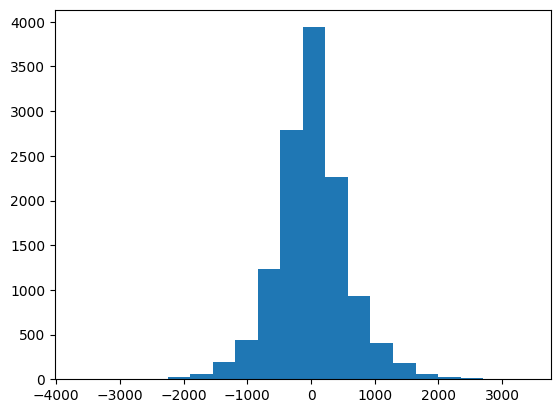

In [18]:
plt.hist(total_returns, bins = 20)

(np.float64(16.49326335877826), np.float64(572.6212592888995))
-3667.500000000006


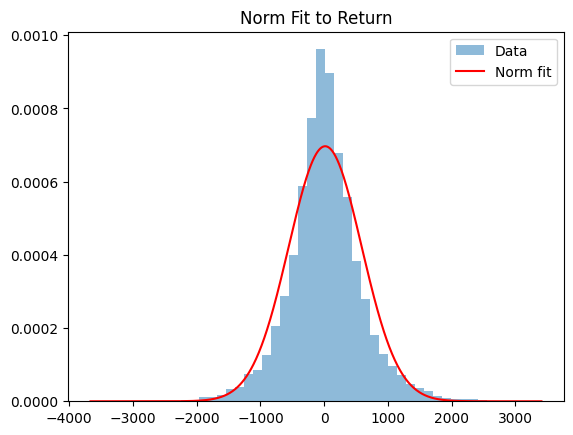

In [ ]:
params_norm = norm.fit(total_returns) #try to fit a normal distribution to the data
print(params_norm)
print(min(total_returns))

x = np.linspace(total_returns.min(), total_returns.max(), 1000)
pdf = norm.pdf(x, *params_norm)

plt.hist(total_returns, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Norm fit")
plt.legend()
plt.title("Norm Fit to Return")
plt.show()

(np.float64(4.255607846386042), np.float64(6.599774659529304), np.float64(429.60822626627515))
-3667.500000000006


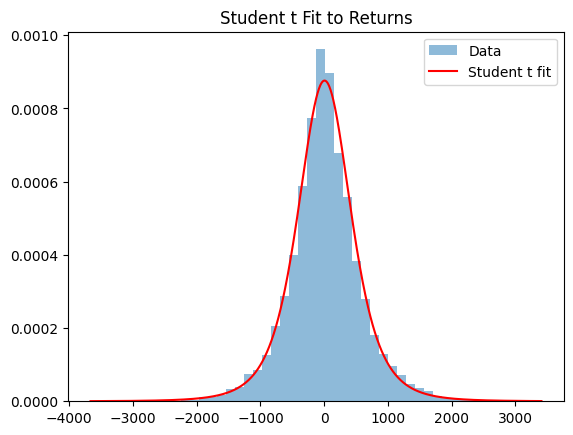

In [ ]:
params_t = t.fit(total_returns) #try to fit a student t distribution to the data
print(params_t)
print(min(total_returns))

x = np.linspace(total_returns.min(), total_returns.max(), 1000)
pdf = t.pdf(x, *params_t)

plt.hist(total_returns, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Student t fit")
plt.legend()
plt.title("Student t Fit to Returns")
plt.show()

It looks like the student-t distribution fits much nicer to the returns associated with the algorithm. This indicates that the algorithm does not perform in a standard normal way, but rather as a student t distribution. However, does this affect much in terms of risk of algorithm performance? At a first sight no, but student t distributions are usually associated with heavier tails when compared to a normal distribution, which may indicate that the algorithm is a bit riskier than one could initially expect.

### Still using the Python code, how would you make your code more generic to include a wider range of risk metrics.

1 and 2 are calculated using the code above.

3 can be calculated calculating the difference between the bid and the ask price, which should not be too complicated to do. Then one can check if different stocks have different spreads, and make decisions on what and where to invest in.

4 can be computed by obtaining key economic indicators and performing a linear regression of them on different values of the stocks. If a succesful regressor is obtained, then one can artificially create big movements of the market and check the algorithms performance under these scenarios.

5, stock correlation is quite easily computed. One can simply check how different stocks are correlated among each other using built in functions of python or numpy. Different positions of the algorithm in different stocks, though, this could potentially be more hard to compute. Different if clauses should be created and timehorizons should also be taken into account to check for possible correlations of different positions. Tied into this, risk number 7 can be computed by checking how much could be lost in short positions and the available cash that could be used to safeguard or protect against this positions. If the biggest losses are still much smaller than the safenet, then the credit risk should not be taken into account. If not though, then it would be something to consider. 

# Market survellaince section
You now want to know whether the algo is misbehaving (from a market regulation perspective). What kind of metrics would you look at?

1. Expectation vs live trading. Backtest could be performed on a given period of time for the algorithm to make sure it behaved as it expected. If its trades deviate a lot from what was expected, then a breach could potentially be found. However, I cannot implement this right now because I do not have access to the actual algorithm

2. Checking Order to Trade ratio (OTR). Exchanges use OTR to monitor trading behavior, especially in high-frequency trading, because an excessive high OTR ratio can sometimes create market anomalies. It can also be considered as quote stuffing, where a trader can send a lot of trades for a security and instantly cancel them to create a false impression of supply and demand. A similar metric is the fill ratio, which is the number of filled trades with respect to the number of created trades. 

3. Spoofing. Spoofing is a manipulative practice. It involves a trader placing large orders on one side of the order book without intending to execute them to create an artificial imbalance. It is quite similar to the previous point, but this is a more local indicator rather than a global one like the previous ones.

In [21]:
OTR = len(orders)/len(filtered)

In [22]:
OTR

5.3707379836412095

In [26]:
fill_ratio = len(filtered)/len(orders[orders["order_status"]=="CREATE"])

In [27]:
fill_ratio

0.37495477179138165

The first value indicates that the algorithm has a 5.37 OTR associated to it. From researching in the internet, this does not seems a high number, thus, it looks like from a market regulation perspective the algorithm performs legally or morally. The same is indicated by the fill ratio.

In [48]:
number_fill = np.mean(filtered["quantity"])
dev_fill = np.std(filtered["quantity"])
number_create = np.mean(orders[orders["order_status"]=="CREATE"]["quantity"])
dev_create = np.std(orders[orders["order_status"]=="CREATE"]["quantity"])

In [49]:
print(number_fill, dev_fill)
print(number_create, dev_create)

1772.6786140979689 2099.924433962664
1316.629025310567 1565.487861581364


(array([5.582e+03, 6.470e+03, 3.380e+03, 1.244e+03, 2.302e+03, 4.530e+02,
        1.530e+02, 9.900e+01, 1.671e+03, 4.500e+01, 1.900e+01, 4.300e+01,
        5.900e+01, 2.400e+01, 3.000e+00, 1.100e+01, 7.500e+01, 3.000e+00,
        4.000e+00, 5.000e+00, 1.300e+01, 0.000e+00, 6.000e+00, 2.000e+00,
        3.400e+01, 0.000e+00, 3.000e+00, 2.000e+00, 0.000e+00, 5.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 2.500e+01, 0.000e+00, 0.000e+00,
        1.000e+00, 3.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 9.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 5.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

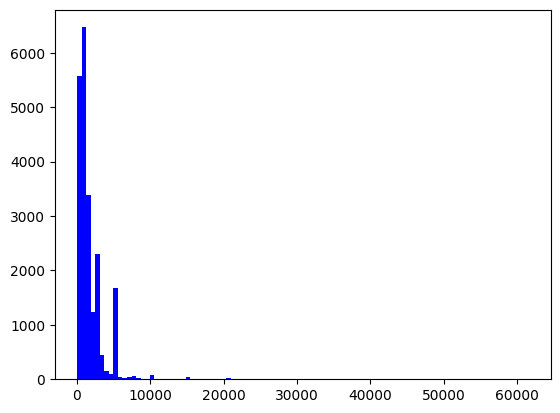

In [44]:
plt.hist(filtered[["quantity"]], color="blue", bins = 100)
#plt.hist(orders[orders["order_status"]=="CREATE"]["quantity"], color="red", bins = 100)

(array([2.2384e+04, 1.6846e+04, 7.3940e+03, 2.3100e+03, 4.8020e+03,
        7.7400e+02, 2.5300e+02, 1.2000e+02, 2.7400e+03, 4.7000e+01,
        2.2000e+01, 4.3000e+01, 5.9000e+01, 2.4000e+01, 3.0000e+00,
        1.1000e+01, 7.8000e+01, 3.0000e+00, 4.0000e+00, 5.0000e+00,
        1.3000e+01, 0.0000e+00, 6.0000e+00, 2.0000e+00, 3.4000e+01,
        0.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00, 5.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 2.5000e+01, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 3.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 9.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

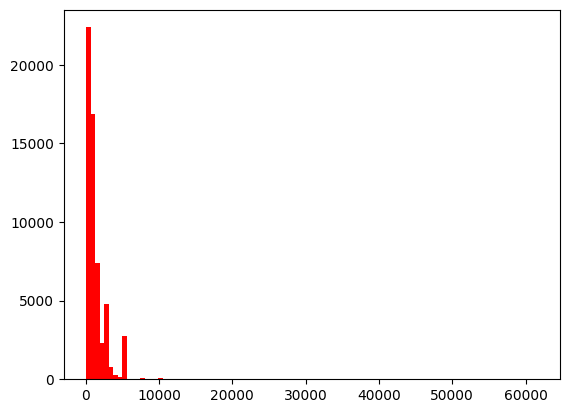

In [45]:
plt.hist(orders[orders["order_status"]=="CREATE"]["quantity"], color="red", bins = 100)

The distribution of number of orders for both fill and create orders seem quite similar, indicating that there is no spoofing in action. Orders significantly larger than the typical order sizes in a given market indicate spoofing. This is also highlighted by the mean and standard deviation of the number of shares. To also check spoofing we might need to check other market orders from other traders.

In [54]:
times = []
for i in range(len(orders)-1):
    if orders.iloc[i]["order_status"]=="CREATE" and orders.iloc[i+1]["order_status"]=="CANCEL":
        t1 = datetime.strptime(orders.iloc[i+1]["timestamp"], "%Y-%m-%d %H:%M:%S")
        t2 = datetime.strptime(orders.iloc[i]["timestamp"], "%Y-%m-%d %H:%M:%S")
        td = t1 - t2
        times.append(td.total_seconds())


In [64]:
np.percentile(times, 15)

np.float64(1.0)

(array([5.959e+03, 0.000e+00, 0.000e+00, 4.590e+02, 1.315e+03, 2.182e+03,
        2.591e+03, 3.809e+03, 4.838e+03, 3.970e+03, 3.866e+03, 2.968e+03,
        2.112e+03, 1.064e+03, 3.920e+02, 1.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 1.000e+00]),
 array([  0. ,   6.7,  13.4,  20.1,  26.8,  33.5,  40.2,  46.9,  53.6,
         60.3,  67. ,  73.7,  80.4,  87.1,  93.8, 100.5, 107.2, 113.9,
        120.6, 127.3, 134. ]),
 <BarContainer object of 20 artists>)

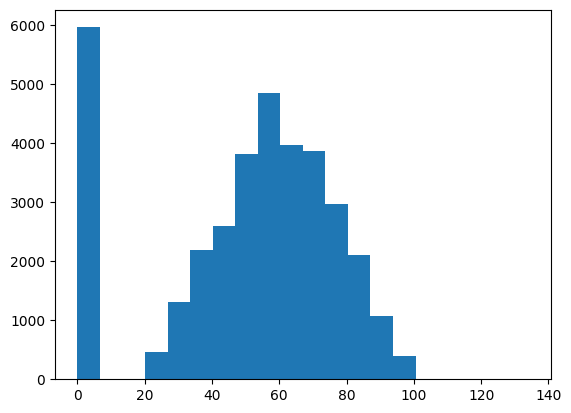

In [58]:
plt.hist(times, bins = 20)

Shorter time differences between order creations and cancellations also indicate spoofing. In this case, the bulk of the orders is close to 60 seconds (which might still indicate spoofing, but is not as clear) thus seeming that there is no spoofing. However, there is also a significant part of the shares close to a time difference of 0. This could potentially draw some spoofing accusations, but it is a bit strange because there are no values between 1 and 20 seconds. Might be that it is a programming error or data acquisition error.

### The next two code windows need a lot of time to run (aprox 20 minutes each), thus, do not run it! It's a nice way of estimating spoofing more accurately (perhaps not code optimal though) but it simply takes too long

In [75]:
canceled = orders[orders["order_status"]=="CANCEL"]

In [87]:
'''canceled
window = timedelta(seconds = 30)
spoofs = []
print(len(canceled))
threshold = 2
for i in range(len(canceled)-10):
    #pick up values to adjust different orders to different price movements of the market
    time = canceled.iloc[i+5]["timestamp"]
    symbol = canceled.iloc[i+5]["symbol"]
    trade = canceled.iloc[i+5]["side"]
    
    symbol_prices = market_data[market_data["symbol"] == symbol].sort_values("timestamp")

    #pick up the previous and posterior 5 trading prices 
    pre = symbol_prices[symbol_prices["timestamp"] < time].tail(5)
    post = symbol_prices[symbol_prices["timestamp"] > time].head(5)

    # calculate the averages for both cases
    pre_mid = pre[["bid_price", "ask_price"]].mean(axis=1).mean()
    post_mid = post[["bid_price", "ask_price"]].mean(axis=1).mean()

    #calculate the standard deviations for both cases
    pre_mid_std = pre[["bid_price", "ask_price"]].std(axis=1).mean()
    post_mid_std = post[["bid_price", "ask_price"]].std(axis=1).mean()

    # Detect spoofing for a given threshold
    # if it's a cancelled sell then it's spoofing if the posterior price is considerably higher than the previous ones
    # if it's a cancelled sell then it's spoofing if the posterior price is considerably lower than the previous ones
    if trade == "SELL" and post_mid - threshold*post_mid_std > pre_mid + threshold*pre_mid_std:
        spoofs.append(1)
    elif trade == "BUY" and post_mid + threshold*post_mid_std < pre_mid - threshold*pre_mid_std:
        spoofs.append(1)

print("Fraction of possible spoofy trading actions:", len(spoofs)/len(canceled))'''



36277
Fraction of possible spoofy trading actions: 0.11916641398131048


This number indicates that under a given criteria, 12% of the trading cancellations could be considered as spoofing actions. It is quite a high number, perhaps indicating that the requirements is too soft for a movement in price to be considered spoofing.


In [88]:
'''filtered
window = timedelta(seconds = 30)
spoofs = []
print(len(filtered))
threshold = 2
for i in range(len(filtered)-10):
    #pick up values to adjust different orders to different price movements of the market
    time = filtered.iloc[i+5]["timestamp"]
    symbol = filtered.iloc[i+5]["symbol"]
    trade = filtered.iloc[i+5]["side"]
    
    symbol_prices = market_data[market_data["symbol"] == symbol].sort_values("timestamp")

    #pick up the previous and posterior 5 trading prices 
    pre = symbol_prices[symbol_prices["timestamp"] < time].tail(5)
    post = symbol_prices[symbol_prices["timestamp"] > time].head(5)

    # calculate the averages for both cases
    pre_mid = pre[["bid_price", "ask_price"]].mean(axis=1).mean()
    post_mid = post[["bid_price", "ask_price"]].mean(axis=1).mean()

    #calculate the standard deviations for both cases
    pre_mid_std = pre[["bid_price", "ask_price"]].std(axis=1).mean()
    post_mid_std = post[["bid_price", "ask_price"]].std(axis=1).mean()

    # Detect spoofing for a given threshold
    # if it's a cancelled sell then it's spoofing if the posterior price is considerably higher than the previous ones
    # if it's a cancelled sell then it's spoofing if the posterior price is considerably lower than the previous ones
    if trade == "SELL" and post_mid - threshold*post_mid_std > pre_mid + threshold*pre_mid_std:
        spoofs.append(1)
    elif trade == "BUY" and post_mid + threshold*post_mid_std < pre_mid - threshold*pre_mid_std:
        spoofs.append(1)

print("Fraction of random spoofy trading actions from fill trades:", len(spoofs)/len(filtered))'''

21762
Fraction of random spoofy trading actions from fill trades: 0.34739454094292804


Takin individually, a 12% of spoofing for the cancelled trades might seems like the algorithm might be manipulating the market. Nevertheless, when looked at actual trades, we see that the portion of trades that fulfill the spoofing criteria is higher (~35%)! This shows that the algorithm is not manipulating nor spoofing the market.

# Derivatives

Let's assume that instead of a cash equity strategy, the trader decides to trade a new directional alpha on implied volatility using options. What additional risk metrics would you suggest in addition to question 1.a?

1. Counterparty risk. If one of the parties (in our case, the other party) involved in a derivative trade defaults on the contract, then this translates into a less profitable trade for the other party. If the contract is traded OTC, then its risk is higher than if it were ETC. 

2. Leverage risk. One could also associate leverage risk with counterparty risk, counterparty risk might be due to leverage risk but there is not a direct implication. Derivatives allow you to use leverage, that is, you can place a small initial amount to enter a derivative contract, but the value of the underlying is much bigger. Thus, small movements of the underlying might result in enormous changes in the price to be paid or received

3. Time sensitivity. Derivatives have an expiration date, unlike with stocks, which in principle you could hold them eternally (if the company does not go bankrupt). Here though, any time prediction is a risky one, since if it is after the expiry date then the derivative price will be unaffected and if it way sooner your expectation of the effect on the final price will no longer be accurate.

4. Model risk. If the algorithm relies upon predictions made by Black Scholes explicit formulas for pricing derivatives, then the model is implicitly making some assumptions about the underlyings that may not necessarily be true. If the underlying asset's behavior deviates significantly from the predictions made by mathematical theories, then the algorithm will have a risk associated to this deviation. And even more if the implied volatility of the underlyings is obtained using those formulas. If it is using volatility smiles then the risk may be a bit mitigated.

5. Systemic Risk A failure of any single institution or major derivatives market event can establish systemic risk, which spreads financial instability throughout various markets. A single player’s collapse from this risk establishes a sequence of events that produces broad market issues and possibly triggers a financial crisis.